# Morphométrie descriptive des cinq conditions

**Question.** Les effets déjà vus sur l'épaisseur corticale se retrouvent-ils, dans le même sens, sur la surface corticale, le volume cortical et les volumes sous-corticaux ?

**Définition unique, identique au boxplot d'épaisseur de la phase 4.** Pour chaque acquisition (sujet × run × condition), on calcule la **distance signée** à la référence individuelle :

distance = valeur(acquisition) − valeur(**brut/run-01 du même sujet**)

- La référence est toujours `brut/run-01` du même sujet. C'est le scan le moins traité et le plus immobile, une référence opérationnelle, pas une vérité anatomique parfaite.
- Distance **signée** : négatif = la mesure a diminué par rapport au brut immobile, positif = elle a augmenté. `brut/run-01` vaut donc 0 par construction.
- Unité statistique : une valeur par acquisition ; les boxplots montrent la distribution entre sujets.

**Deux compartiments de matière grise.**

- **Cortex :** épaisseur (mm), surface (mm²) et volume cortical (mm³). Elles sont liées : `volume ≈ surface × épaisseur`.
- **Noyaux gris profonds :** masses centrales décrites par leur volume. Leur total est `SubCortGrayVol` (mm³).

L'agrégation diffère selon la mesure et c'est volontaire : moyenne pour l'épaisseur (comme en phase 4), somme pour surface et volumes (une surface et un volume sont additifs, le total est la mesure globale naturelle).

**Source unique** : `results/ds004332/phase5_fidelity/morphometry_long.csv`, produite par `extract_morphometry_stats.py` (une seule table pour les cinq conditions). Aucun modèle Agitation. Le dernier bloc ajoute uniquement le test demandé sur les trois consignes de mouvement.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, HTML

HOME = Path.home()
def find_repo():
    for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        if (p / "results/ds004332/phase5_fidelity").exists():
            return p
    return HOME / "Documents/jdac-motion-correction"
REPO = find_repo()
MORPH = REPO / "results/ds004332/phase5_fidelity/morphometry_long.csv"

CONDITIONS = ["brut", "preproc", "jdac", "jdac_antiartonly", "jdac_nodenoise"]
SHORT = {"brut":"brut", "preproc":"prep", "jdac":"jdac",
         "jdac_antiartonly":"aa×1", "jdac_nodenoise":"aa×4"}
CONSIGNE = {"run-01":"still", "run-02":"nodding", "run-03":"shaking"}
COLORS = {"still":"tab:green", "nodding":"tab:orange", "shaking":"tab:red"}
OFFSETS = {"still":-0.23, "nodding":0.0, "shaking":0.23}

# Garde : la source doit exister. Sinon on indique exactement quoi exécuter.
if not MORPH.is_file():
    print("Fichier source absent :", MORPH)
    print()
    print("Il est produit par extract_morphometry_stats.py à partir des sorties FreeSurfer")
    print("(lh/rh.aparc.stats pour surface et volume cortical, aseg.stats pour les volumes)")
    print("des CINQ conditions. Surface et volume cortical ne sont PAS disponibles en local")
    print("pour l'instant ; il faut lancer l'extraction sur Narval ou le PC labo :")
    print()
    print("  python pipelines/ds004332/phase5_fidelity/extract_morphometry_stats.py \\")
    print("    --root brut=<SUBJECTS_DIR_brut> \\")
    print("    --root preproc=<SUBJECTS_DIR_preproc> \\")
    print("    --root jdac=<SUBJECTS_DIR_jdac> \\")
    print("    --root jdac_antiartonly=<SUBJECTS_DIR_antiartonly> \\")
    print("    --root jdac_nodenoise=<SUBJECTS_DIR_nodenoise>")
    print()
    print("Colonnes attendues : subject, run, condition, family, hemi, region, metric, value, unit.")
    print("Relancer ce notebook une fois le CSV présent.")
    raise SystemExit("morphometry_long.csv manquant : voir le message ci-dessus.")

d = pd.read_csv(MORPH)
d = d[d["condition"].isin(CONDITIONS)].copy()
d["consigne"] = d["run"].map(CONSIGNE)
print("Source :", MORPH)
print(f"{len(d):,} lignes | {d['subject'].nunique()} sujets | "
      f"{d[['subject','run','condition']].drop_duplicates().shape[0]} acquisitions")
print("familles :", ", ".join(sorted(d["family"].unique())))

Source : C:\Users\Mathilde\Documents\GitHub\jdac-motion-correction\results\ds004332\phase5_fidelity\morphometry_long.csv
86,116 lignes | 22 sujets | 325 acquisitions
familles : aseg_global, aseg_region, cortical_region


## Méthode commune

Toutes les figures utilisent la même référence individuelle et la même convention de signe. Les fonctions ci-dessous ne produisent aucune analyse supplémentaire ; elles garantissent seulement que les quatre mesures sont calculées de façon identique.

In [2]:
def par_acquisition(d, family, metric, agg, region=None, positive_only=False):
    """Une valeur par (sujet, run, condition) : agg des régions d'une mesure."""
    sub = d[(d["family"] == family) & (d["metric"] == metric)].copy()
    if region is not None:
        sub = sub[sub["region"] == region]
    if positive_only:
        sub = sub[sub["value"] > 0]
    per = (sub.groupby(["subject","run","condition"], observed=True)["value"]
              .agg(agg).reset_index(name="value"))
    return per

def distance_a_reference(per):
    """Ajoute la distance signée à brut/run-01 du même sujet."""
    ref = (per[(per["condition"] == "brut") & (per["run"] == "run-01")]
           [["subject","value"]].rename(columns={"value":"ref"}))
    per = per.merge(ref, on="subject", how="inner")
    per["dist"] = per["value"] - per["ref"]
    per["consigne"] = per["run"].map(CONSIGNE)
    return per

def box_distance(ax, per, titre, unite):
    groups = []
    for i, c in enumerate(CONDITIONS):
        for cons in ["still","nodding","shaking"]:
            vals = per[(per["condition"] == c) & (per["consigne"] == cons)]["dist"].dropna()
            if vals.empty:
                continue
            groups.append(vals)
            pos = i + OFFSETS[cons]
            bp = ax.boxplot(vals, positions=[pos], widths=0.18, patch_artist=True,
                            showfliers=False, medianprops={"color":"black","lw":1.3})
            bp["boxes"][0].set(facecolor=COLORS[cons], alpha=0.28, edgecolor=COLORS[cons])
            for it in bp["whiskers"] + bp["caps"]:
                it.set(color=COLORS[cons], alpha=0.7)
            jitter = np.linspace(-0.035, 0.035, len(vals))
            ax.scatter(pos + jitter, vals, s=11, color=COLORS[cons], alpha=0.5)
    ax.axhline(0, color="black", ls="--", lw=1.1)
    ax.set_xticks(range(len(CONDITIONS)))
    ax.set_xticklabels([SHORT[c] for c in CONDITIONS], rotation=20)
    ax.set_title(titre, fontsize=12)
    ax.set_ylabel(f"écart à brut/run-01 ({unite})")
    ax.grid(axis="y", alpha=0.18)
    # Cadrage robuste : borner l'axe sur les boîtes et leurs moustaches (Tukey,
    # 1.5x IQR), 0 inclus, pour ne pas etre dezoome par quelques valeurs extremes.
    # Les points hors fenetre sont comptes et signales sous la figure.
    lows, highs, n_hors = [], [], 0
    for v in groups:
        q1, q3 = v.quantile(0.25), v.quantile(0.75)
        iqr = q3 - q1
        lo_f, hi_f = q1 - 1.5*iqr, q3 + 1.5*iqr
        inl = v[(v >= lo_f) & (v <= hi_f)]
        if len(inl):
            lows.append(inl.min()); highs.append(inl.max())
        n_hors += int(((v < lo_f) | (v > hi_f)).sum())
    if lows:
        lo, hi = min(lows + [0.0]), max(highs + [0.0])
        span = (hi - lo) or 1.0
        ax.set_ylim(lo - 0.08*span, hi + 0.08*span)
    return n_hors

def legende_consignes(fig):
    handles = [plt.Line2D([], [], marker="o", ls="", color=COLORS[c],
               label={"still":"run-01 immobile","nodding":"run-02 nodding","shaking":"run-03 shaking"}[c])
               for c in ["still","nodding","shaking"]]
    fig.legend(handles=handles, loc="lower center", ncol=3, frameon=False, fontsize=11)

def _color(t, fmt="{:.1f}"):
    """Colore un tableau d'écarts en % : rouge = baisse, bleu = hausse, centré sur 0."""
    arr = t.to_numpy(dtype=float)
    vmax = float(np.nanmax(np.abs(arr))) if arr.size else 1.0
    vmax = vmax or 1.0
    return (t.style.format(fmt)
             .background_gradient(cmap="RdBu", vmin=-vmax, vmax=vmax, axis=None)
             .set_properties(**{"text-align": "center"}))

## Partie 1 — Le cortex : épaisseur, surface, volume (trois mesures liées)

Le cortex est la fine écorce de matière grise pliée à la surface du cerveau. On le décrit ici par ses trois mesures corticales, **côte à côte pour les lire ensemble** : elles ne sont pas indépendantes (`volume ≈ surface × épaisseur`, vérifié juste après).

**Question posée.** Sur un scan immobile (points verts), le traitement déplace-t-il déjà la mesure par rapport au brut, et sur les scans bougés (orange, rouge) se rapproche-t-il ou s'éloigne-t-il de la référence ?

**Comment lire.** La ligne pointillée à 0 est le brut/run-01 du sujet. Une boîte proche de 0 = mesure proche de la référence. Une boîte **sous** 0 = mesure plus petite que le brut immobile (amincissement, perte de surface ou de volume) ; **au-dessus** de 0 = plus grande. La cohérence attendue est que les trois bougent dans le même sens.

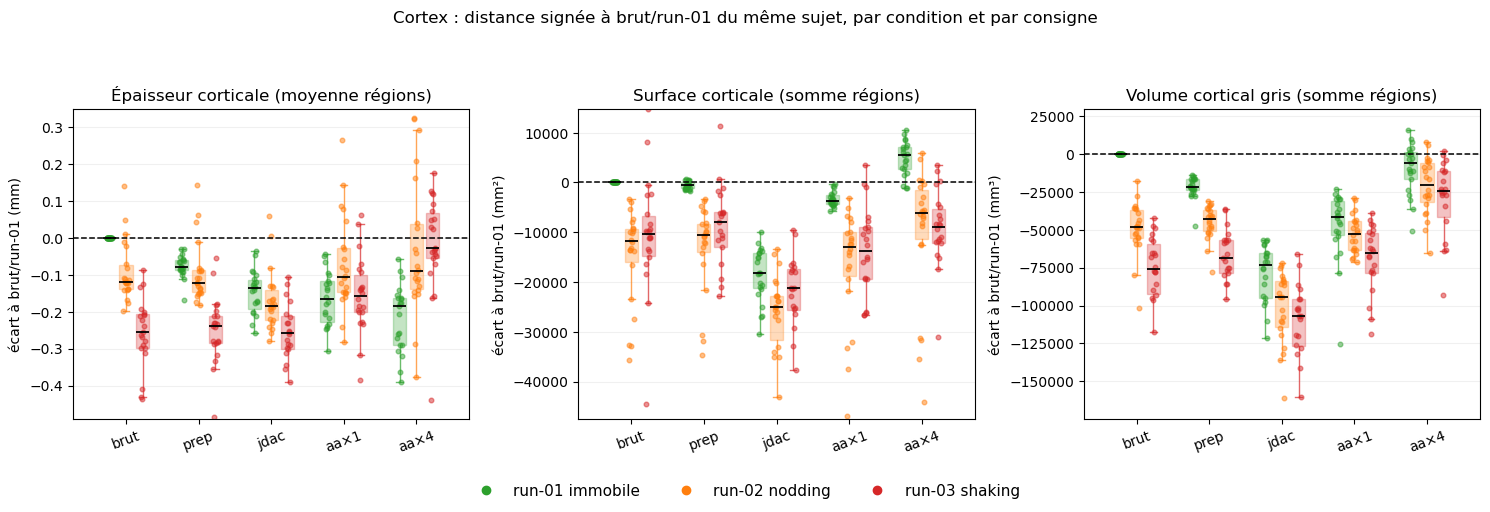

*Axes cadrés sur les boîtes et moustaches pour rester lisibles ; 61 points extrêmes (outliers) sont volontairement hors cadre.*

In [3]:
MESURES = [
    ("Épaisseur corticale (moyenne régions)", "mm",
     par_acquisition(d, "cortical_region", "thickness", "mean", positive_only=True)),
    ("Surface corticale (somme régions)", "mm²",
     par_acquisition(d, "cortical_region", "surface_area", "sum")),
    ("Volume cortical gris (somme régions)", "mm³",
     par_acquisition(d, "cortical_region", "cortical_gray_volume", "sum")),
]
manquantes = [titre for titre, _, per in MESURES if per.empty]
if manquantes:
    display(Markdown("**Mesures absentes de la source (panneau vide) :** " + ", ".join(manquantes)
                     + ". Vérifier que `lh/rh.aparc.stats` ont bien été extraits pour les cinq conditions."))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
n_hors = 0
for ax, (titre, unite, per) in zip(axes.flat, MESURES):
    if per.empty:
        ax.set_title(titre + " (données absentes)", fontsize=12); ax.set_axis_off(); continue
    n_hors += box_distance(ax, distance_a_reference(per), titre, unite)
fig.suptitle("Cortex : distance signée à brut/run-01 du même sujet, par condition et par consigne", y=1.0)
fig.tight_layout(rect=[0, 0.08, 1, 0.94])
legende_consignes(fig)
plt.show()
if n_hors:
    display(Markdown(f"*Axes cadrés sur les boîtes et moustaches pour rester lisibles ; {n_hors} points extrêmes (outliers) sont volontairement hors cadre.*"))

### Résultats corticaux

Le tableau résume les boxplots en pourcentage de la référence individuelle. `brut/run-01` vaut 0 par construction. Un correcteur utile devrait rapprocher les scans bougés de 0 **sans déplacer le scan still**.

In [4]:
def _median_pct(family, metric, agg, pos=False, region=None):
    per = distance_a_reference(par_acquisition(d, family, metric, agg, region=region, positive_only=pos))
    per["pct"] = 100 * (per["value"] - per["ref"]) / per["ref"]
    t = (per.groupby(["condition","consigne"], observed=True)["pct"]
            .median().unstack("consigne").reindex(CONDITIONS)[["still","nodding","shaking"]])
    t.index = [SHORT[c] for c in t.index]
    t.columns = ["still (run1)", "nodding (run2)", "shaking (run3)"]
    return t

tab_ep = _median_pct("cortical_region", "thickness", "mean", pos=True)
tab_su = _median_pct("cortical_region", "surface_area", "sum")
tab_vo = _median_pct("cortical_region", "cortical_gray_volume", "sum")

resume_cortex = pd.concat(
    {"Épaisseur": tab_ep, "Surface": tab_su, "Volume cortical": tab_vo},
    names=["Mesure", "Traitement"],
)
display(Markdown("**Écart médian à brut/run-01 (%)** — rouge = baisse, bleu = hausse"))
display(_color(resume_cortex))

display(Markdown(
    "**Lecture principale**\n\n"
    f"- Sur le scan **still**, JDAC déplace déjà le volume cortical de {tab_vo.loc['jdac','still (run1)']:.1f} % : il modifie une image qui nécessite peu de correction.\n"
    f"- **aa×1** limite cette déformation (surface {tab_su.loc['aa×1','still (run1)']:.1f} % contre {tab_su.loc['jdac','still (run1)']:.1f} % pour JDAC), mais cette variante change à la fois le débruiteur et le nombre de passes.\n"
    f"- **aa×4** paraît meilleure sur le volume cortical en shaking ({tab_vo.loc['aa×4','shaking (run3)']:.1f} %), mais l'épaisseur baisse pendant que la surface augmente : les erreurs se compensent.\n"
    "- L'épaisseur seule ne suffit donc pas. Les trois mesures doivent être lues ensemble (`volume ≈ surface × épaisseur`)."))

**Écart médian à brut/run-01 (%)** — rouge = baisse, bleu = hausse

**Lecture principale**

- Sur le scan **still**, JDAC déplace déjà le volume cortical de -14.2 % : il modifie une image qui nécessite peu de correction.
- **aa×1** limite cette déformation (surface -2.0 % contre -10.3 % pour JDAC), mais cette variante change à la fois le débruiteur et le nombre de passes.
- **aa×4** paraît meilleure sur le volume cortical en shaking (-4.6 %), mais l'épaisseur baisse pendant que la surface augmente : les erreurs se compensent.
- L'épaisseur seule ne suffit donc pas. Les trois mesures doivent être lues ensemble (`volume ≈ surface × épaisseur`).

## Partie 2 — Les noyaux gris profonds (le sous-cortical)

Au centre du cerveau, sous le cortex, se trouvent des masses grises pleines. Elles n'ont ni surface ni épaisseur, seulement un **volume**. FreeSurfer en fait le total `SubCortGrayVol`, qui est **exactement la somme de huit structures** (gauche + droit) : thalamus, noyau caudé, putamen, pallidum, hippocampe, amygdale, noyau accumbens et diencéphale ventral (VentralDC).

**Question posée.** Les traitements préservent-ils le volume sous-cortical total ? Les huit structures détaillées restent disponibles dans un tableau repliable, sans neuf boxplots supplémentaires.

**Comment lire.** Volumes bilatéraux (gauche + droit) en mm³, même distance signée à brut/run-01. Sous 0 = structure plus petite qu'au brut immobile ; au-dessus = plus grande. Contrairement au cortex, aucune relation `surface × épaisseur` ici : ce ne sont que des volumes.

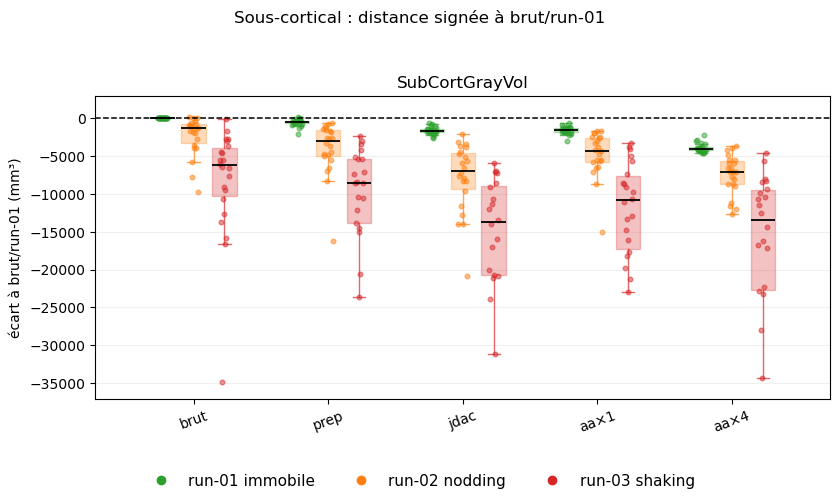

*Axe cadré sur les boîtes et moustaches ; 21 points extrêmes sont hors cadre.*

In [5]:
COMPOSANTES = [
    ("Thalamus", "Thalamus"),
    ("Noyau caudé", "Caudate"),
    ("Putamen", "Putamen"),
    ("Pallidum", "Pallidum"),
    ("Hippocampe", "Hippocampus"),
    ("Amygdale", "Amygdala"),
    ("Accumbens", "Accumbens"),
    ("Diencéphale ventral", "VentralDC"),
]
aseg_reg = d[d["family"] == "aseg_region"].copy()

per_subcort = par_acquisition(d, "aseg_global", "volume", "sum", region="SubCortGrayVol")
fig, ax = plt.subplots(figsize=(8.5, 5))
n_hors = box_distance(ax, distance_a_reference(per_subcort), "SubCortGrayVol", "mm³")
fig.suptitle("Sous-cortical : distance signée à brut/run-01", y=0.98)
fig.tight_layout(rect=[0, 0.10, 1, 0.94])
legende_consignes(fig)
plt.show()
if n_hors:
    display(Markdown(f"*Axe cadré sur les boîtes et moustaches ; {n_hors} points extrêmes sont hors cadre.*"))

### Lecture chiffrée : le total et ses composantes

Les mêmes écarts en médiane et en pourcentage. Le premier tableau suit `SubCortGrayVol` par consigne (comme en partie 1) ; le second détaille les huit composantes sur le scan immobile, pour voir si le total vient de tous les noyaux ou de quelques-uns.

In [6]:
tab_scv = _median_pct("aseg_global", "volume", "sum", region="SubCortGrayVol")
display(Markdown("**SubCortGrayVol (total) — médiane de l'écart à brut/run-01 (%)** — rouge = baisse, bleu = hausse"))
display(_color(tab_scv))

def _comp_run01_pct():
    rows = {}
    for nom, motif in COMPOSANTES:
        sub = aseg_reg[aseg_reg["region"].str.contains(motif, na=False)]
        per = (sub.groupby(["subject","run","condition"], observed=True)["value"]
                  .sum().reset_index(name="value"))
        per = distance_a_reference(per)
        per["pct"] = 100 * (per["value"] - per["ref"]) / per["ref"]
        rows[nom] = (per[per["run"] == "run-01"].groupby("condition", observed=True)["pct"]
                     .median().reindex(CONDITIONS))
    t = pd.DataFrame(rows).T
    t.columns = [SHORT[c] for c in t.columns]
    return t

comp = _comp_run01_pct()
display(HTML(
    "<details><summary><b>Voir les huit structures sur le scan still</b></summary>"
    + comp.round(1).to_html() + "</details>"
))

display(Markdown(
    "**Résultats sous-corticaux**\n\n"
    f"- JDAC modifie déjà le scan still : SubCortGrayVol {tab_scv.loc['jdac','still (run1)']:.1f} %.\n"
    f"- En shaking, toutes les conditions restent sous la référence : brut {tab_scv.loc['brut','shaking (run3)']:.1f} %, JDAC {tab_scv.loc['jdac','shaking (run3)']:.1f} %, aa×4 {tab_scv.loc['aa×4','shaking (run3)']:.1f} %.\n"
    "- Le total masque des structures qui changent dans des sens opposés ; le détail est conservé pour vérification, mais ne constitue pas la conclusion principale.\n"
    "- L'avantage apparent de aa×4 sur le volume cortical ne se retrouve donc pas dans les noyaux profonds."))

**SubCortGrayVol (total) — médiane de l'écart à brut/run-01 (%)** — rouge = baisse, bleu = hausse

,still (run1),nodding (run2),shaking (run3)
brut,0.0,-1.9,-9.2
prep,-0.6,-4.9,-13.6
jdac,-2.5,-11.5,-19.9
aa×1,-2.4,-6.6,-17.6
aa×4,-6.1,-11.0,-20.0


,brut,prep,jdac,aa×1,aa×4
Thalamus,0.0,-1.7,2.1,-4.3,-2.2
Noyau caudé,0.0,-0.2,-9.8,-4.7,-2.5
Putamen,0.0,-1.0,-9.2,-6.3,-12.3
Pallidum,0.0,-0.7,-3.3,4.1,-6.7
Hippocampe,0.0,-0.9,-4.9,-4.4,-7.8
Amygdale,0.0,-1.4,-7.5,-2.0,-3.8
Accumbens,0.0,-2.4,-8.5,-2.0,-9.8
Diencéphale ventral,0.0,1.5,6.4,2.0,-0.5


**Résultats sous-corticaux**

- JDAC modifie déjà le scan still : SubCortGrayVol -2.5 %.
- En shaking, toutes les conditions restent sous la référence : brut -9.2 %, JDAC -19.9 %, aa×4 -20.0 %.
- Le total masque des structures qui changent dans des sens opposés ; le détail est conservé pour vérification, mais ne constitue pas la conclusion principale.
- L'avantage apparent de aa×4 sur le volume cortical ne se retrouve donc pas dans les noyaux profonds.

## Le mouvement modifie-t-il encore les mesures après traitement ?

**But du test demandé.** Les boxplots suggèrent un ordre entre still, nodding et shaking. Le test vérifie si ces écarts sont reproductibles entre sujets, au lieu de reposer sur une impression visuelle.

Un test apparié compare chaque sujet à lui-même :

`différence du sujet = mesure en shaking − mesure en still`

Comme il y a **trois** états, l'analyse fait d'abord un test global à mesures répétées, puis les trois comparaisons appariées (`nodding − still`, `shaking − still`, `shaking − nodding`) avec correction de Holm.

**Interprétation.** Une différence négative signifie que la mesure baisse avec le mouvement. Ce test dit si le mouvement reste associé à la morphométrie **dans une condition donnée**. Il ne classe pas directement les correcteurs ; ce classement demandera ensuite un contraste `traitement − preproc` sur le même run.

In [7]:
from scipy import stats

MOUVEMENTS = ["still", "nodding", "shaking"]
PAIRES = [
    ("nodding − still", "nodding", "still"),
    ("shaking − still", "shaking", "still"),
    ("shaking − nodding", "shaking", "nodding"),
]

TESTS_PRIMAIRES = [
    ("Épaisseur corticale", "mm",
     par_acquisition(d, "cortical_region", "thickness", "mean", positive_only=True)),
    ("Surface corticale", "mm²",
     par_acquisition(d, "cortical_region", "surface_area", "sum")),
    ("Volume cortical", "mm³",
     par_acquisition(d, "cortical_region", "cortical_gray_volume", "sum")),
    ("SubCortGrayVol", "mm³",
     par_acquisition(d, "aseg_global", "volume", "sum", region="SubCortGrayVol")),
]

def holm(p_values):
    """Correction de Holm ; NaN reste NaN."""
    p = np.asarray(p_values, dtype=float)
    out = np.full(p.shape, np.nan)
    keep = np.flatnonzero(np.isfinite(p))
    if not len(keep):
        return out
    order = keep[np.argsort(p[keep])]
    running = 0.0
    n = len(order)
    for rank, idx in enumerate(order):
        running = max(running, (n - rank) * p[idx])
        out[idx] = min(1.0, running)
    return out

def anova_rm_3(wide):
    """ANOVA à un facteur répété, trois états ; sans dépendance statsmodels."""
    x = wide[MOUVEMENTS].to_numpy(dtype=float)
    n, k = x.shape
    if n < 2 or np.isclose(np.var(x), 0):
        return np.nan, np.nan, np.nan, np.nan
    grand = x.mean()
    ss_total = ((x - grand) ** 2).sum()
    ss_mouvement = n * ((x.mean(axis=0) - grand) ** 2).sum()
    ss_sujet = k * ((x.mean(axis=1) - grand) ** 2).sum()
    ss_erreur = ss_total - ss_mouvement - ss_sujet
    df1, df2 = k - 1, (n - 1) * (k - 1)
    if ss_erreur <= np.finfo(float).eps:
        return np.nan, df1, df2, np.nan
    f = (ss_mouvement / df1) / (ss_erreur / df2)
    return f, df1, df2, stats.f.sf(f, df1, df2)

def _p(p):
    if not np.isfinite(p):
        return "—"
    return "< 0,001" if p < 0.001 else f"= {p:.3f}".replace(".", ",")

def _contraste(wide, apres, avant, unite):
    diff = wide[apres] - wide[avant]
    n = len(diff)
    t, p = stats.ttest_rel(wide[apres], wide[avant], nan_policy="omit")
    moyenne = diff.mean()
    se = stats.sem(diff, nan_policy="omit")
    if n > 1 and np.isfinite(se):
        borne = stats.t.ppf(0.975, n - 1) * se
        ic = (moyenne - borne, moyenne + borne)
    else:
        ic = (np.nan, np.nan)
    decimals = 3 if unite == "mm" else 0
    fmt = f"{{:.{decimals}f}}"
    texte = f"Δ {fmt.format(moyenne)} [{fmt.format(ic[0])} ; {fmt.format(ic[1])}] {unite}"
    return texte, p

rows, details = [], {}
for mesure, unite, per_brut in TESTS_PRIMAIRES:
    per = distance_a_reference(per_brut)
    for condition in CONDITIONS:
        wide = (per[per["condition"] == condition]
                .pivot(index="subject", columns="consigne", values="dist")
                .reindex(columns=MOUVEMENTS).dropna())
        f, df1, df2, p_global = anova_rm_3(wide)
        rows.append({
            "Mesure": mesure,
            "condition_code": condition,
            "Traitement": SHORT[condition],
            "n sujets": len(wide),
            "F": f,
            "df2": df2,
            "p globale brute": p_global,
        })
        details[(mesure, condition)] = (wide, unite)

tests = pd.DataFrame(rows)
tests["p globale Holm"] = holm(tests["p globale brute"])
for nom, _, _ in PAIRES:
    tests[nom] = "non testé : test global non significatif"

for idx, row in tests.iterrows():
    if not np.isfinite(row["p globale Holm"]) or row["p globale Holm"] >= 0.05:
        continue
    wide, unite = details[(row["Mesure"], row["condition_code"])]
    textes, ps = [], []
    for nom, apres, avant in PAIRES:
        texte, p = _contraste(wide, apres, avant, unite)
        textes.append(texte)
        ps.append(p)
    p_holm = holm(ps)
    for (nom, _, _), texte, p_corr in zip(PAIRES, textes, p_holm):
        tests.loc[idx, nom] = f"{texte}; p Holm {_p(p_corr)}"

tests["Test global (ANOVA RM)"] = tests.apply(
    lambda r: (f"F(2, {int(r['df2'])}) = {r['F']:.2f}; p Holm {_p(r['p globale Holm'])}"
               if np.isfinite(r["F"]) else "non calculable"),
    axis=1,
)
tests = tests[["Mesure", "Traitement", "n sujets", "Test global (ANOVA RM)",
               "nodding − still", "shaking − still", "shaking − nodding"]]

import re

def _cellule_principale(texte):
    if texte.startswith("non testé"):
        return "test global NS"
    m = re.match(r"Δ ([^[]+) \[[^]]+\] ([^;]+); p Holm (.+)", texte)
    return f"Δ {m.group(1)} {m.group(2)} ; p {m.group(3)}" if m else texte

principal = tests.pivot(index="Mesure", columns="Traitement", values="shaking − still")
principal = principal.reindex(index=[m[0] for m in TESTS_PRIMAIRES], columns=[SHORT[c] for c in CONDITIONS])
principal = principal.map(_cellule_principale)
display(Markdown(
    "**Résultat principal : shaking − still.** `Δ` est la différence moyenne appariée. "
    "Une p-value Holm < 0,05 signifie que la différence résiste à la correction des comparaisons."))
display(principal.style.set_properties(**{"text-align": "center", "font-size": "90%"}))

def _delta(mesure, condition, apres="shaking", avant="still"):
    wide, _ = details[(mesure, condition)]
    return float((wide[apres] - wide[avant]).mean())

display(Markdown(
    "**Ce que les tests montrent**\n\n"
    "- Dans le brut et le preproc, le mouvement réduit les quatre mesures : le biais morphométrique attendu est bien détecté.\n"
    f"- JDAC atténue la baisse d'épaisseur en shaking (Δ {_delta('Épaisseur corticale','jdac'):.3f} mm, contre {_delta('Épaisseur corticale','preproc'):.3f} mm en preproc), "
    f"mais accentue la baisse de SubCortGrayVol (Δ {_delta('SubCortGrayVol','jdac'):.0f} mm³, contre {_delta('SubCortGrayVol','preproc'):.0f} mm³).\n"
    f"- aa×4 inverse l'épaisseur (Δ {_delta('Épaisseur corticale','jdac_nodenoise'):+.3f} mm) alors que surface et volumes baissent encore : cela indique une compensation entre mesures, pas une restauration anatomique démontrée.\n"
    "- Conclusion du test : aucune condition n'annule de façon cohérente l'effet du mouvement sur toutes les mesures."))

display(HTML(
    "<details><summary><b>Voir le tableau statistique complet (test global, trois paires et IC95 %)</b></summary>"
    + tests.to_html(index=False) + "</details>"
))
display(Markdown(
    "*Les différences sujet par sujet sont parfois asymétriques. Les tailles d'effet et IC95 % restent donc prioritaires ; "
    "un Wilcoxon apparié sert de contrôle de sensibilité pour les conclusions limites.*"))

**Résultat principal : shaking − still.** `Δ` est la différence moyenne appariée. Une p-value Holm < 0,05 signifie que la différence résiste à la correction des comparaisons.

Traitement,brut,prep,jdac,aa×1,aa×4
Mesure,,,,,
Épaisseur corticale,"Δ -0.256 mm ; p < 0,001","Δ -0.168 mm ; p < 0,001","Δ -0.090 mm ; p = 0,006","Δ 0.023 mm ; p = 0,326","Δ 0.202 mm ; p < 0,001"
Surface corticale,"Δ -13442 mm² ; p = 0,006","Δ -10344 mm² ; p = 0,003","Δ -4433 mm² ; p = 0,069","Δ -12627 mm² ; p < 0,001","Δ -17566 mm² ; p = 0,001"
Volume cortical,"Δ -99615 mm³ ; p < 0,001","Δ -51180 mm³ ; p < 0,001","Δ -29204 mm³ ; p < 0,001","Δ -27132 mm³ ; p = 0,012","Δ -29965 mm³ ; p = 0,090"
SubCortGrayVol,"Δ -8325 mm³ ; p < 0,001","Δ -10603 mm³ ; p < 0,001","Δ -14459 mm³ ; p < 0,001","Δ -11711 mm³ ; p < 0,001","Δ -13931 mm³ ; p < 0,001"


**Ce que les tests montrent**

- Dans le brut et le preproc, le mouvement réduit les quatre mesures : le biais morphométrique attendu est bien détecté.
- JDAC atténue la baisse d'épaisseur en shaking (Δ -0.090 mm, contre -0.168 mm en preproc), mais accentue la baisse de SubCortGrayVol (Δ -14459 mm³, contre -10603 mm³).
- aa×4 inverse l'épaisseur (Δ +0.202 mm) alors que surface et volumes baissent encore : cela indique une compensation entre mesures, pas une restauration anatomique démontrée.
- Conclusion du test : aucune condition n'annule de façon cohérente l'effet du mouvement sur toutes les mesures.

Mesure,Traitement,n sujets,Test global (ANOVA RM),nodding − still,shaking − still,shaking − nodding
Épaisseur corticale,brut,21,"F(2, 40) = 81.57; p Holm < 0,001","Δ -0.087 [-0.123 ; -0.051] mm; p Holm < 0,001","Δ -0.256 [-0.298 ; -0.214] mm; p Holm < 0,001","Δ -0.169 [-0.217 ; -0.120] mm; p Holm < 0,001"
Épaisseur corticale,prep,20,"F(2, 38) = 37.19; p Holm < 0,001","Δ -0.014 [-0.057 ; 0.029] mm; p Holm = 0,502","Δ -0.168 [-0.214 ; -0.122] mm; p Holm < 0,001","Δ -0.154 [-0.200 ; -0.107] mm; p Holm < 0,001"
Épaisseur corticale,jdac,20,"F(2, 38) = 9.84; p Holm = 0,002","Δ -0.005 [-0.057 ; 0.047] mm; p Holm = 0,840","Δ -0.090 [-0.146 ; -0.035] mm; p Holm = 0,006","Δ -0.085 [-0.118 ; -0.052] mm; p Holm < 0,001"
Épaisseur corticale,aa×1,22,"F(2, 42) = 8.37; p Holm = 0,002","Δ 0.106 [0.038 ; 0.174] mm; p Holm = 0,010","Δ 0.023 [-0.025 ; 0.072] mm; p Holm = 0,326","Δ -0.083 [-0.135 ; -0.031] mm; p Holm = 0,010"
Épaisseur corticale,aa×4,21,"F(2, 40) = 20.15; p Holm < 0,001","Δ 0.169 [0.096 ; 0.243] mm; p Holm < 0,001","Δ 0.202 [0.138 ; 0.265] mm; p Holm < 0,001","Δ 0.032 [-0.044 ; 0.109] mm; p Holm = 0,385"
Surface corticale,brut,22,"F(2, 42) = 9.06; p Holm = 0,002","Δ -14680 [-18925 ; -10435] mm²; p Holm < 0,001","Δ -13442 [-21795 ; -5088] mm²; p Holm = 0,006","Δ 1239 [-8859 ; 11337] mm²; p Holm = 0,801"
Surface corticale,prep,20,"F(2, 38) = 12.01; p Holm < 0,001","Δ -13056 [-17258 ; -8854] mm²; p Holm < 0,001","Δ -10344 [-16173 ; -4515] mm²; p Holm = 0,003","Δ 2712 [-4516 ; 9939] mm²; p Holm = 0,442"
Surface corticale,jdac,20,"F(2, 38) = 10.07; p Holm = 0,002","Δ -8640 [-11846 ; -5434] mm²; p Holm < 0,001","Δ -4433 [-8509 ; -356] mm²; p Holm = 0,069","Δ 4207 [-464 ; 8879] mm²; p Holm = 0,075"
Surface corticale,aa×1,22,"F(2, 42) = 11.84; p Holm < 0,001","Δ -13218 [-18194 ; -8241] mm²; p Holm < 0,001","Δ -12627 [-18950 ; -6304] mm²; p Holm < 0,001","Δ 591 [-6985 ; 8167] mm²; p Holm = 0,873"
Surface corticale,aa×4,21,"F(2, 40) = 10.33; p Holm = 0,002","Δ -13151 [-17874 ; -8428] mm²; p Holm < 0,001","Δ -17566 [-26660 ; -8472] mm²; p Holm = 0,001","Δ -4415 [-14717 ; 5887] mm²; p Holm = 0,382"


*Les différences sujet par sujet sont parfois asymétriques. Les tailles d'effet et IC95 % restent donc prioritaires ; un Wilcoxon apparié sert de contrôle de sensibilité pour les conclusions limites.*

## Conclusion

- Le mouvement diminue épaisseur, surface, volume cortical et `SubCortGrayVol` dans le brut et le preproc.
- JDAC atténue l'effet apparent sur l'épaisseur, mais pas sur toutes les mesures : il accentue notamment la baisse sous-corticale et modifie déjà le scan still.
- aa×4 produit une compensation épaisseur↓/surface↑ ; un volume cortical proche de la référence ne suffit donc pas à conclure à une anatomie restaurée.
- Le test apparié confirme un effet du mouvement dans chaque condition. Il ne classe pas encore les correcteurs : l'étape suivante est une comparaison directe de chaque méthode à `preproc` sur les mêmes scans.